---
# Laboratório 07 (Parte 2): Encoding Avançado (Alta Cardinalidade)
**Aula 09 | Disciplina:** Extração e Preparação de Dados (IBM8915)

**O Problema:** O que acontece quando temos uma variável nominal com milhares de categorias únicas (ex: CEP, ID de Produto, Cidade)? Se usarmos o `pd.get_dummies()`, criaremos milhares de colunas, estourando a memória RAM (Overfitting e lentidão). 
**A Solução:** Em vez de criar colunas booleanas, vamos substituir o texto por estatísticas baseadas no próprio dataset (*Frequency Encoding* e *Target Encoding*).

**TÉCNICA 1**: Frequency Encoding

Substitui a categoria pela frequência (%) com que ela aparece na base
O método value_counts(normalize=True) nos dá a frequência, e to_dict() vira um mapa

**Exemplo:**
```python
dicionario_frequencia=df['categoria'].value_counts(normalize=True).to_dict()
```
O método .map() aceita um dicionário para fazer a substituição ágil
```python
df['categoria_frequencia'] = df['categoria'].map(dicionario_frequencia)
```

**TÉCNICA 2**: Target Encoding (Mean Encoding)

Substitui a categoria pela média da variável alvo (Ex: Qual a taxa de fraude deste CEP?)
Agrupamos por CEP e tiramos a média da coluna Fraude

**Exemplo:**
```python
dicionario_target=df.groupby('cep')['fraude'].mean().to_dict()
df['cep_media_fraude'] = df['cep'].map(dicionario_target)
```


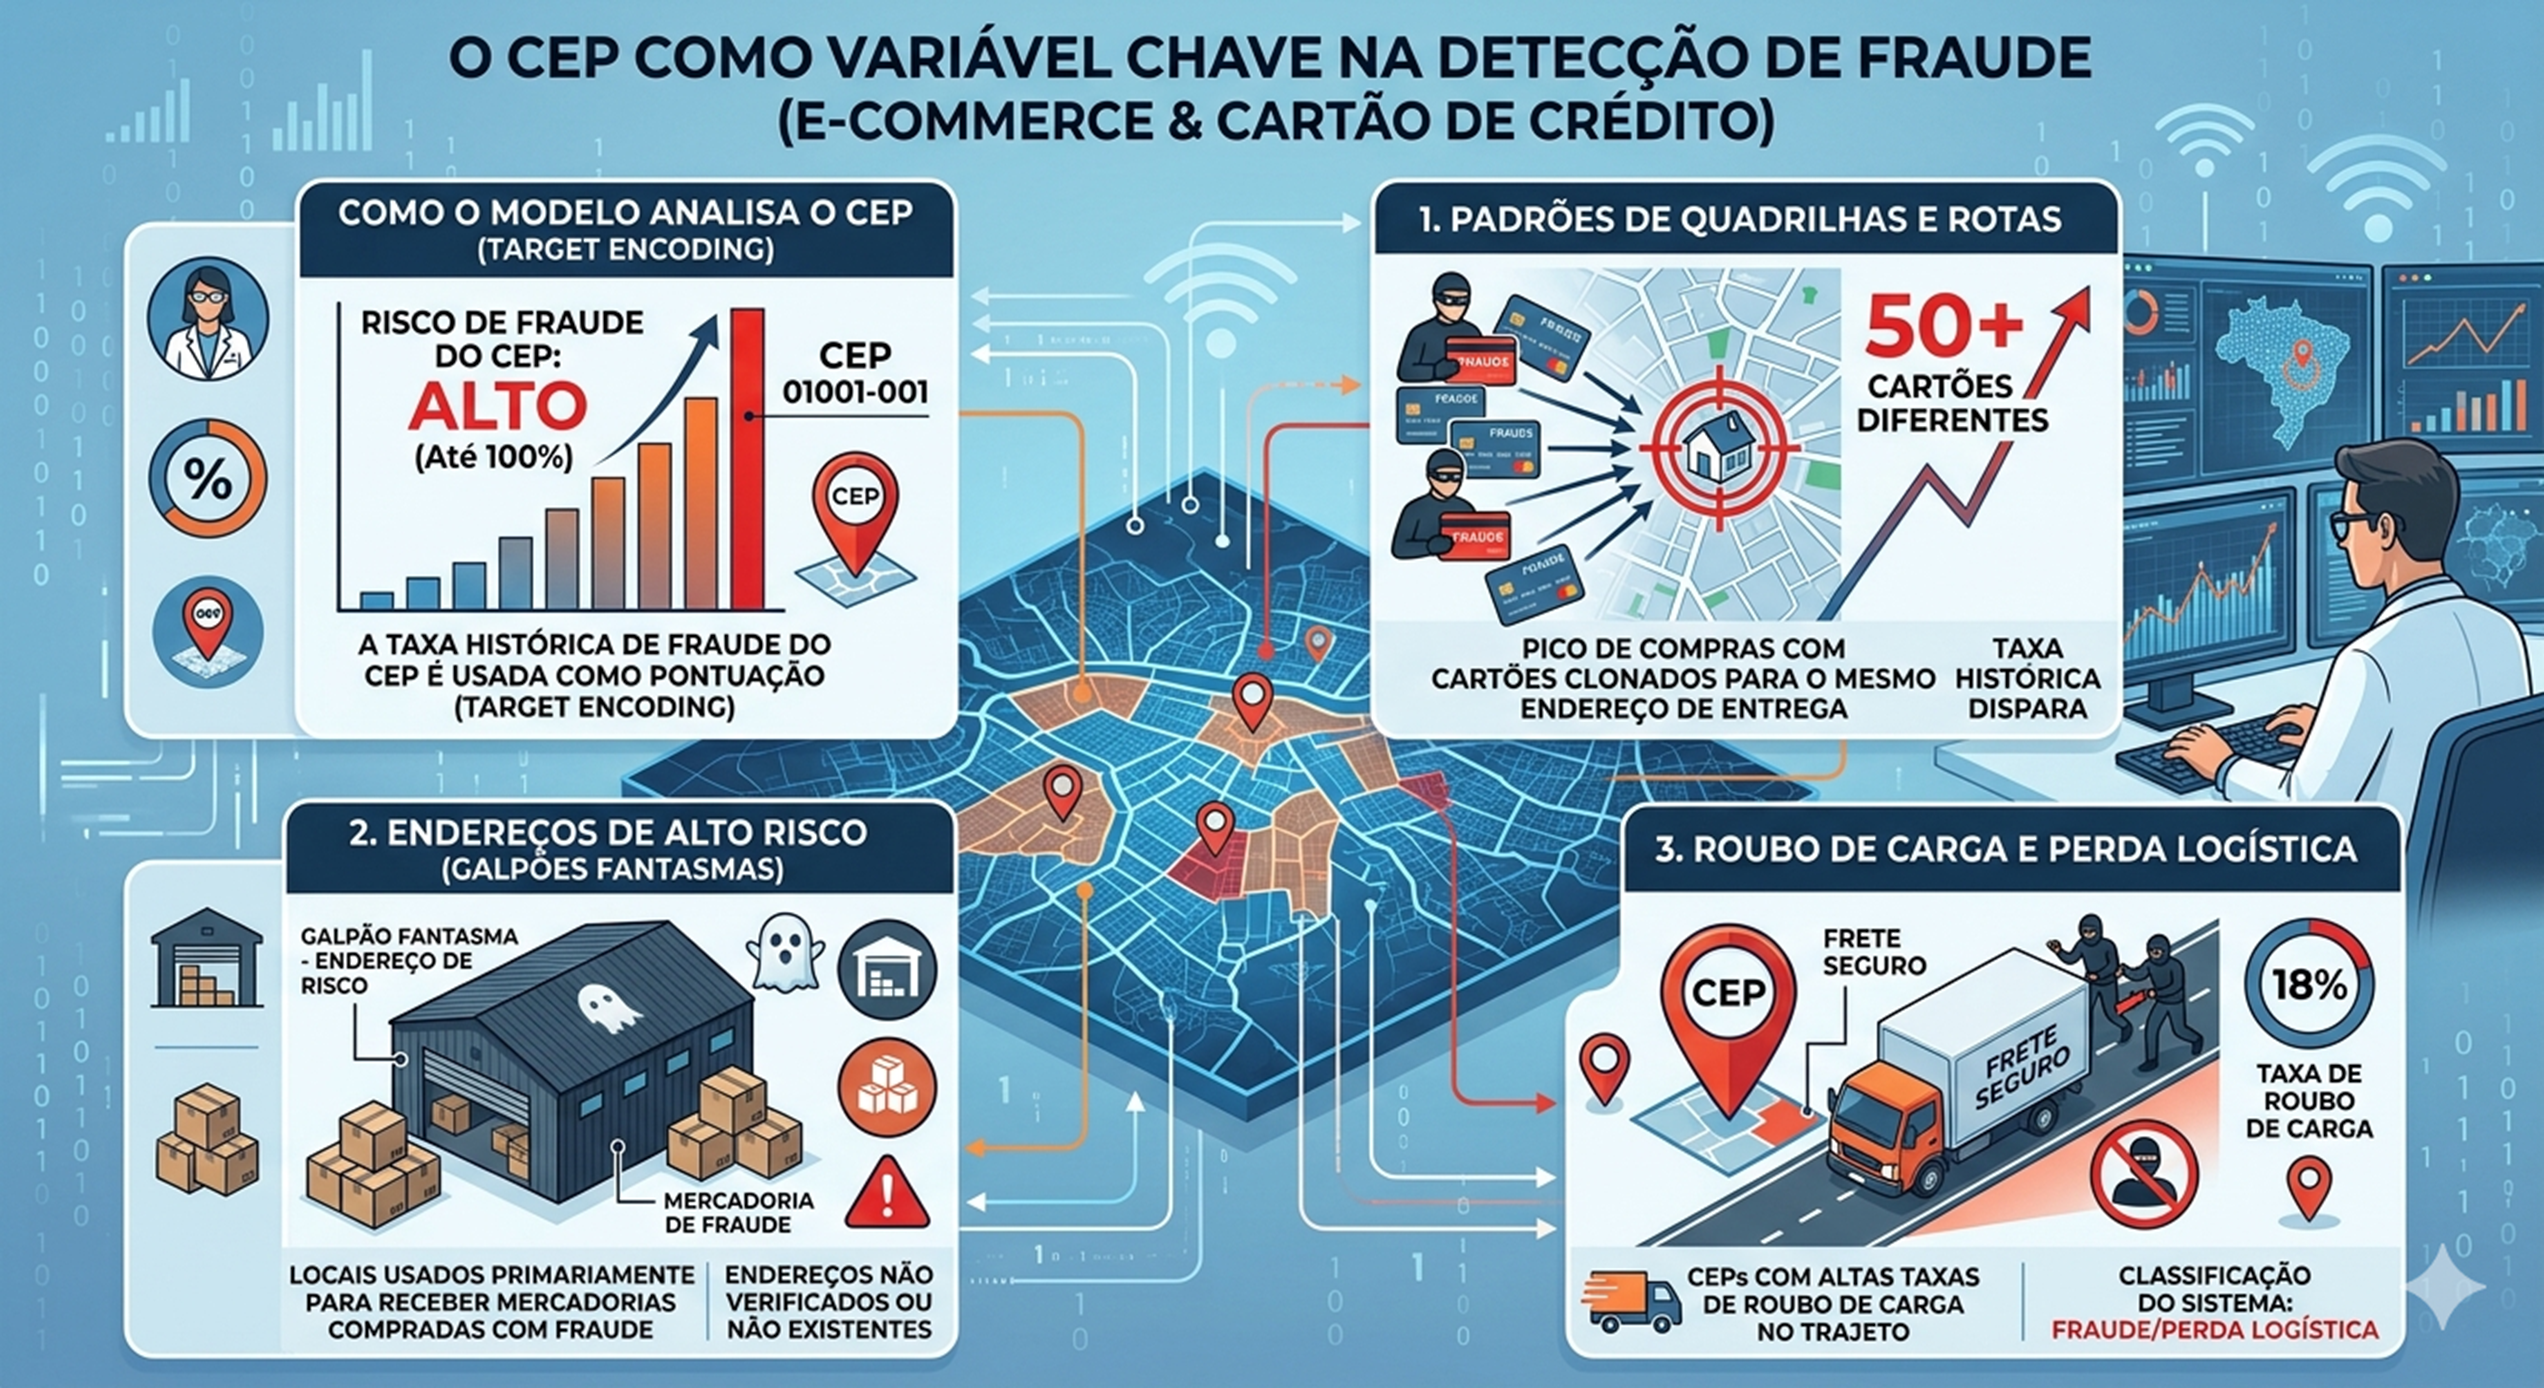

In [1]:
import pandas as pd
import numpy as np

# 1. Gerando um dataset simulado com alta cardinalidade (100 CEPs diferentes)
np.random.seed(42)
ceps = [f"CEP-{i}" for i in range(1000, 1100)] # 100 Categorias únicas
df_fraude = pd.DataFrame({
    'ID_Transacao': range(1, 501),
    'CEP_Origem': np.random.choice(ceps, 500),
    'Fraude': np.random.choice([0, 1], 500, p=[0.85, 0.15]) # Variável Alvo (Target)
})

print("Tamanho original:", df_fraude.shape)
print("Categorias Únicas em CEP:", df_fraude['CEP_Origem'].nunique(), "\n")


Tamanho original: (500, 3)
Categorias Únicas em CEP: 99 



In [2]:
# --- TÉCNICA 1: Frequency Encoding ---
# Substitui a categoria pela frequência (%) com que ela aparece na base
# O método value_counts(normalize=True) nos dá a frequência, e to_dict() vira um mapa
dicionario_frequencia = df_fraude['CEP_Origem'].value_counts(normalize=True).to_dict()

# O método .map() aceita um dicionário para fazer a substituição ágil
df_fraude['CEP_Frequencia'] = df_fraude['CEP_Origem'].map(dicionario_frequencia)

# --- TÉCNICA 2: Target Encoding (Mean Encoding) ---
# Substitui a categoria pela MÉDIA da variável alvo (Ex: Qual a taxa de fraude deste CEP?)
# Agrupamos por CEP e tiramos a média da coluna Fraude
dicionario_target = df_fraude.groupby('CEP_Origem')['Fraude'].mean().to_dict()
df_fraude['CEP_Probabilidade_Fraude'] = df_fraude['CEP_Origem'].map(dicionario_target)

print("--- Dados Transformados (Sem estourar a matriz) ---")
display(df_fraude[['CEP_Origem', 'Fraude', 'CEP_Frequencia', 'CEP_Probabilidade_Fraude']].head(5))

--- Dados Transformados (Sem estourar a matriz) ---


,CEP_Origem,Fraude,CEP_Frequencia,CEP_Probabilidade_Fraude
0,CEP-1051,0,0.014,0.285714
1,CEP-1092,0,0.016,0.125000
2,CEP-1014,0,0.016,0.000000
3,CEP-1071,0,0.010,0.000000
4,CEP-1060,0,0.008,0.000000


## Parte 4: Exercício Prático (Target Encoding)
Você é o engenheiro de dados de um aplicativo de delivery. Você tem uma base de dados contendo milhares de `Bairros` e a variável alvo `Atraso_Entrega` (0 = No prazo, 1 = Atrasado).

**Sua Tarefa:**
1. Rodar a célula abaixo para gerar os dados.
2. Calcular a taxa média de atraso para cada bairro usando `groupby().mean()`.
3. Converter esse agrupamento em um dicionário Python (`.to_dict()`).
4. Criar uma nova coluna numérica chamada `Risco_Atraso` aplicando o seu dicionário na coluna `Bairro` com o método `.map()`.


In [10]:
# NÃO ALTERE ESTE CÓDIGO - Geração do cenário do exercício
bairros_cidade = [f"Bairro_{i}" for i in range(1, 151)] # 150 Bairros diferentes
df_delivery = pd.DataFrame({
    'Pedido_ID': range(1, 801),
    'Bairro': np.random.choice(bairros_cidade, 800),
    'Valor_Conta': np.random.uniform(20, 150, 800),
    'Atraso_Entrega': np.random.choice([0, 1], 800, p=[0.7, 0.3]) # Target
})
display(df_delivery.head(3))

,Pedido_ID,Bairro,Valor_Conta,Atraso_Entrega
0,1,Bairro_63,43.747410,0
1,2,Bairro_110,38.147853,0
2,3,Bairro_69,94.941417,0


In [11]:
# Passo 1: Use o groupby para achar a média de 'Atraso_Entrega' por 'Bairro' e transforme em dicionário
dici= (df_delivery.groupby('Bairro')['Atraso_Entrega'].mean()).to_dict()
dici

{'Bairro_1': 1.0,
 'Bairro_10': 0.5,
 'Bairro_100': 0.5,
 'Bairro_101': 0.25,
 'Bairro_102': 0.2,
 'Bairro_103': 0.2,
 'Bairro_104': 0.36363636363636365,
 'Bairro_105': 0.5,
 'Bairro_106': 0.0,
 'Bairro_107': 0.5,
 'Bairro_108': 0.14285714285714285,
 'Bairro_109': 0.2,
 'Bairro_11': 0.2,
 'Bairro_110': 0.0,
 'Bairro_111': 0.5,
 'Bairro_112': 0.42857142857142855,
 'Bairro_113': 0.14285714285714285,
 'Bairro_114': 0.0,
 'Bairro_115': 0.5714285714285714,
 'Bairro_116': 0.14285714285714285,
 'Bairro_117': 0.0,
 'Bairro_118': 0.2,
 'Bairro_119': 0.25,
 'Bairro_12': 0.5,
 'Bairro_120': 0.3333333333333333,
 'Bairro_121': 0.0,
 'Bairro_122': 0.375,
 'Bairro_123': 0.6666666666666666,
 'Bairro_124': 1.0,
 'Bairro_125': 0.2,
 'Bairro_126': 0.0,
 'Bairro_127': 0.1,
 'Bairro_128': 0.5,
 'Bairro_129': 0.1,
 'Bairro_13': 0.3333333333333333,
 'Bairro_130': 0.6666666666666666,
 'Bairro_131': 0.3333333333333333,
 'Bairro_132': 0.2857142857142857,
 'Bairro_133': 0.4,
 'Bairro_134': 0.0,
 'Bairro_135': 0.

In [ ]:
# Passo 2: Use o método .map(mapa_atraso) na coluna Bairro para criar a nova coluna 'Risco_Atraso'
df_delivery['Risco_Atraso'] = df_delivery['Bairro'].map(dici)
df_delivery

,Pedido_ID,Bairro,Valor_Conta,Atraso_Entrega,Risco_Atraso
0,1,Bairro_63,43.747410,0,0.142857
1,2,Bairro_110,38.147853,0,0.000000
2,3,Bairro_69,94.941417,0,0.500000
3,4,Bairro_43,119.044870,0,0.400000
4,5,Bairro_34,121.595734,0,0.333333
...,...,...,...,...,...
795,796,Bairro_145,130.932798,0,0.333333
796,797,Bairro_81,62.660809,0,0.166667
797,798,Bairro_78,26.990401,1,1.000000
798,799,Bairro_6,107.016408,0,0.200000


In [13]:
# Passo 3: Descarte a coluna de texto original 'Bairro' usando drop()
df_delivery.drop(columns=['Bairro'], inplace=True)
# Passo 4: Exiba as 5 primeiras linhas do df_delivery final para comprovar que só sobraram números
df_delivery.head()

,Pedido_ID,Valor_Conta,Atraso_Entrega,Risco_Atraso
0,1,43.747410,0,0.142857
1,2,38.147853,0,0.000000
2,3,94.941417,0,0.500000
3,4,119.044870,0,0.400000
4,5,121.595734,0,0.333333


---
### Conclusão e Próximos Passos
**Parabéns!** Você acabou de resolver um dos maiores problemas de processamento de Machine Learning: a super cardinalidade. 
*   Em categorias pequenas (Cores, Gênero, Status): Usamos **One-Hot Encoding** (`pd.get_dummies`).
*   Em categorias gigantes (CEP, Bairro, ID Cliente): Usamos **Target/Frequency Encoding** (`groupby + map`).

**Na próxima etapa da Aula 09**, aprenderemos a fazer a operação inversa: transformar variáveis numéricas contínuas em variáveis categóricas (faixas/baldes) usando o conceito de **Binning** no notebook `lab_09_binning.ipynb`. Não esqueça de fazer o commit deste notebook no GitHub!